<a href="https://colab.research.google.com/github/davidevigna1/Signal-processing/blob/main/Analisi_Ritmo_Alpha_EEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CELLA DI SETUP


In [1]:
!pip install mne biosppy pyedflib -q

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
%matplotlib inline

print("✅ Laboratorio configurato con successo!")
print(f"Strumenti pronti: MNE, NumPy, Pandas, SciPy, Matplotlib")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 42.1 MB/s eta 0:00:00
✅ Laboratorio configurato con successo!
Strumenti pronti: MNE, NumPy, Pandas, SciPy, Matplotlib


IMPORTAZIONE SEGNALE

In [2]:
data_path = mne.datasets.sample.data_path()
raw_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

raw = mne.io.read_raw_fif(raw_fname, preload=True, verbose=False)

# 3. Selezioniamo solo i sensori che ci servono
raw.pick_types(meg=False, eeg=True, eog=True)

print("✅ Dati caricati!")
print(f"Frequenza di campionamento: {raw.info['sfreq']} Hz")
print(f"Numero di elettrodi EEG: {len(raw.ch_names) - 1}") # -1 perché uno è l'EOG

Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m26s (1576.2 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
✅ Dati caricati!
Frequenza di campionamento: 600.614990234375 Hz
Numero di elettrodi EEG: 59


Using matplotlib as 2D backend.


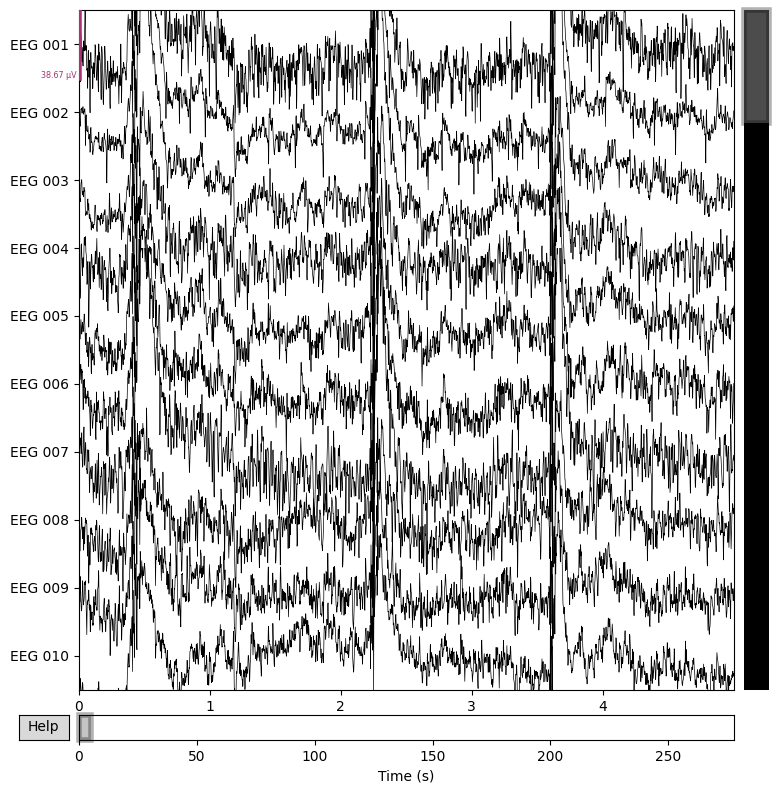

In [3]:
# --- CELLA 3: VISUALIZZAZIONE DEL SEGNALE ---
import matplotlib.pyplot as plt

# 1. Definiamo quanti canali vogliamo vedere (es. 10)
# e per quanti secondi (es. 5 secondi)
n_canali = 10
secondi = 5

# 2. Creiamo il grafico
raw.plot(n_channels=n_canali, duration=secondi, title="Segnale EEG Grezzo (Originale)", scalings='auto')

plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)



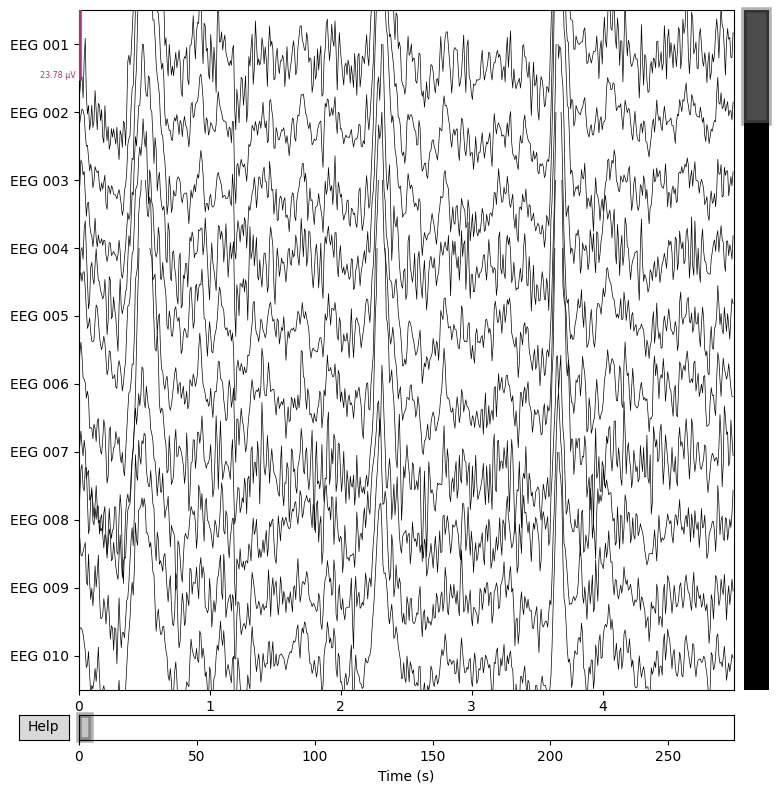

In [4]:
# --- CELLA 4: IL FILTRAGGIO ---

raw_clean = raw.copy()

# 1. Applichiamo il filtro passa-banda da 1 a 40 Hz
raw_clean.filter(l_freq=1.0, h_freq=40.0)

raw_clean.plot(n_channels=10, duration=5, title="Segnale EEG Pulito (1-40 Hz)", scalings='auto')

plt.show()

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


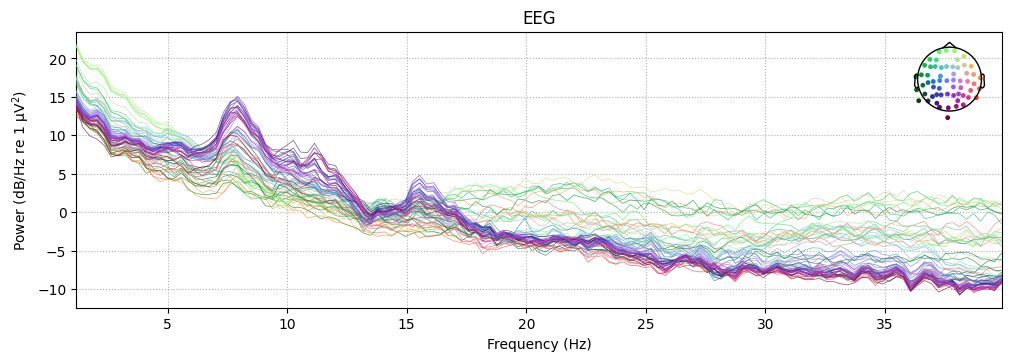

In [5]:
# --- CELLA 5: ANALISI DELLE FREQUENZE (PSD) ---

# 1. Calcoliamo la PSD (Power Spectral Density)
psd = raw_clean.compute_psd(fmin=1.0, fmax=40.0)

# 2. Creiamo il grafico dello Spettro
# Questo grafico mostra la "potenza" (energia) sull'asse Y e la "frequenza" sull'asse X
psd.plot(picks='eeg', exclude='bads')

plt.show()

In [6]:
# --- CELLA 6: TABELLA DEI RISULTATI ---

risultati = {
    "Ritmo": ["Delta", "Theta", "Alpha", "Beta"],
    "Frequenza [Hz]": ["1 - 4", "4 - 8", "8 - 13", "13 - 30"],
    "Funzione": ["Sonno profondo", "Sonnolenza", "Relax/Occhi chiusi", "Attività motoria/Focus"]
}

df_report = pd.DataFrame(risultati)

print("📊 REPORT ANALISI NEUROSCIENTIFICA 📊")
print("-" * 40)
print(df_report.to_string(index=False)) # Mostra la tabella senza i numeri di riga
print("-" * 40)
print("\nAnalisi completata con successo!")

📊 REPORT ANALISI NEUROSCIENTIFICA 📊
----------------------------------------
Ritmo Frequenza [Hz]               Funzione
Delta          1 - 4         Sonno profondo
Theta          4 - 8             Sonnolenza
Alpha         8 - 13     Relax/Occhi chiusi
 Beta        13 - 30 Attività motoria/Focus
----------------------------------------

Analisi completata con successo!
